# ============================================================
# 3_analise.ipynb
# Fase 3 do pipeline: Camada Gold
# Perguntas de negócio + gráficos + tabela e view agregadas
# ============================================================

In [8]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from config import MYSQL_CONFIG


In [10]:
# Configurações de visualização

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [11]:
# Conexão com o banco via SQLAlchemy
usuario  = MYSQL_CONFIG["user"]
senha    = quote_plus(MYSQL_CONFIG["password"])
host     = MYSQL_CONFIG["host"]
porta    = MYSQL_CONFIG["port"]
database = MYSQL_CONFIG["database"]

engine = create_engine(
    f"mysql+mysqlconnector://{usuario}:{senha}@{host}:{porta}/{database}"
)

print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


In [12]:
# ============================================================
# PERGUNTA 1: Os 5 órgãos com maior custo total?
# ============================================================

query_p1 = """
    SELECT
        nome_orgao_superior,
        ROUND(SUM(valor_total), 2) AS custo_total
    FROM silver_viagem
    WHERE valor_total IS NOT NULL
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
"""

df_p1 = pd.read_sql(query_p1, engine)
print(df_p1.to_string(index=False))

                           nome_orgao_superior  custo_total
     Ministério da Justiça e Segurança Pública 486933121.65
                          Ministério da Defesa 156070304.49
                        Ministério da Educação 111291349.34
Ministério do Meio Ambiente e Mudança do Clima  49697710.16
              Ministério da Previdência Social  40417309.06


FileNotFoundError: [Errno 2] No such file or directory: 'images/grafico_p1_orgaos.png'

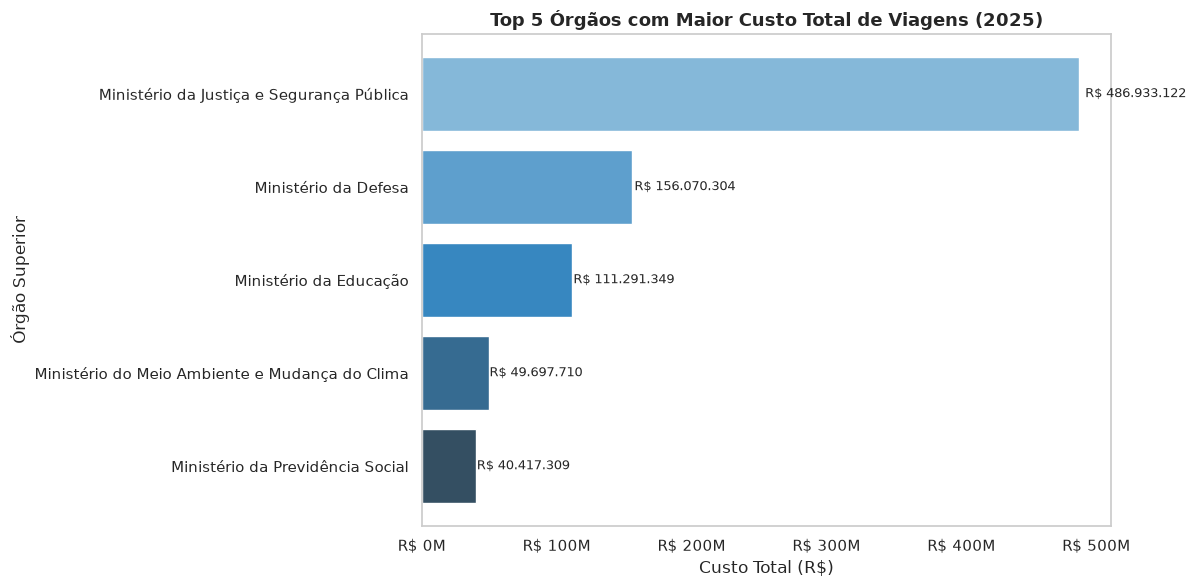

In [ ]:
# Gráfico P1 — 5 órgãos com maior custo total
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    df_p1["nome_orgao_superior"],
    df_p1["custo_total"],
    color=sns.color_palette("Blues_d", len(df_p1))
)

# Inverte para o maior ficar no topo
ax.invert_yaxis()

# Rótulos de valor no final de cada barra
for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.0f}".replace(",", "."),
        va="center", fontsize=9
    )

# Formata eixo X em milhões
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x/1e6:.0f}M")
)

ax.set_title("Top 5 Órgãos com Maior Custo Total de Viagens (2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Custo Total (R$)")
ax.set_ylabel("Órgão Superior")

ax.grid(False)
plt.tight_layout()
plt.savefig("../reports/figures/grafico_p1_orgaos.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# PERGUNTA 2: Os 3 destinos com maior custo médio por viagem?
# ============================================================

query_p2 = """
    SELECT
        t.destino_cidade,
        t.destino_uf,
        COUNT(DISTINCT t.id_viagem)         AS total_viagens,
        ROUND(AVG(v.valor_total), 2)        AS custo_medio
    FROM silver_trecho t
    JOIN silver_viagem v ON t.id_viagem = v.id_viagem
    WHERE v.valor_total IS NOT NULL
        AND t.destino_cidade IS NOT NULL
        AND t.destino_cidade != ''
    GROUP BY t.destino_cidade, t.destino_uf
    ORDER BY custo_medio DESC
    LIMIT 3
"""

df_p2 = pd.read_sql(query_p2, engine)
print(df_p2.to_string(index=False))

destino_cidade destino_uf  total_viagens  custo_medio
        Tejupá  São Paulo              1    115175.00
     Chavantes  São Paulo              1    114557.01
     Teolândia      Bahia              1    109322.50


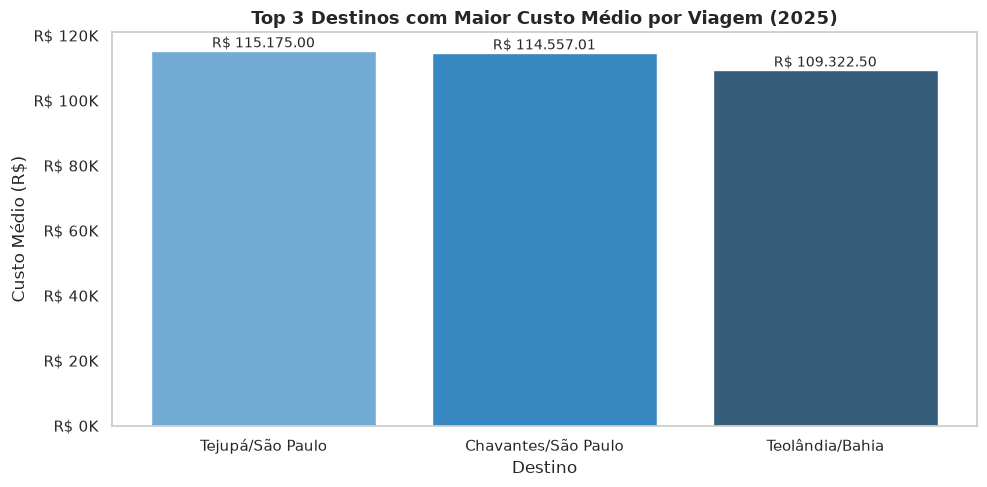

In [ ]:
# Gráfico P2 — 3 destinos com maior custo médio
fig, ax = plt.subplots(figsize=(10, 5))

labels = df_p2["destino_cidade"] + "/" + df_p2["destino_uf"]

bars = ax.bar(
    labels,
    df_p2["custo_medio"],
    color=sns.color_palette("Blues_d", len(df_p2))
)

# Rótulos de valor no topo de cada barra
for bar in bars:
    valor = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor * 1.01,
        f"R$ {valor:,.2f}".replace(",", "."),
        ha="center", fontsize=10
    )

ax.set_title("Top 3 Destinos com Maior Custo Médio por Viagem (2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Destino")
ax.set_ylabel("Custo Médio (R$)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x/1e3:.0f}K")
)
ax.grid(False)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_p2_destinos.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#============================================================
# PERGUNTA 3: A viagem de maior duração e seu custo total? 
#============================================================

query_p3 = """
SELECT
    v.id_viagem,
    v.nome_viajante,
    v.nome_orgao_superior,
    v.destinos,
    v.data_inicio,
    v.data_fim,
    v.duracao_dias,
    v.valor_total
FROM silver_viagem v
WHERE v.duracao_dias IS NOT NULL
ORDER BY v.duracao_dias DESC
LIMIT 1
"""

df_p3 = pd.read_sql(query_p3, engine)
print(df_p3.to_string(index=False))

          id_viagem                     nome_viajante              nome_orgao_superior      destinos data_inicio   data_fim  duracao_dias  valor_total
0000000000020699856 LUISANGELA CORREA FRANCO DE FARIA Ministério da Previdência Social Mogi Mirim/SP  2025-01-13 2026-01-31           383          0.0


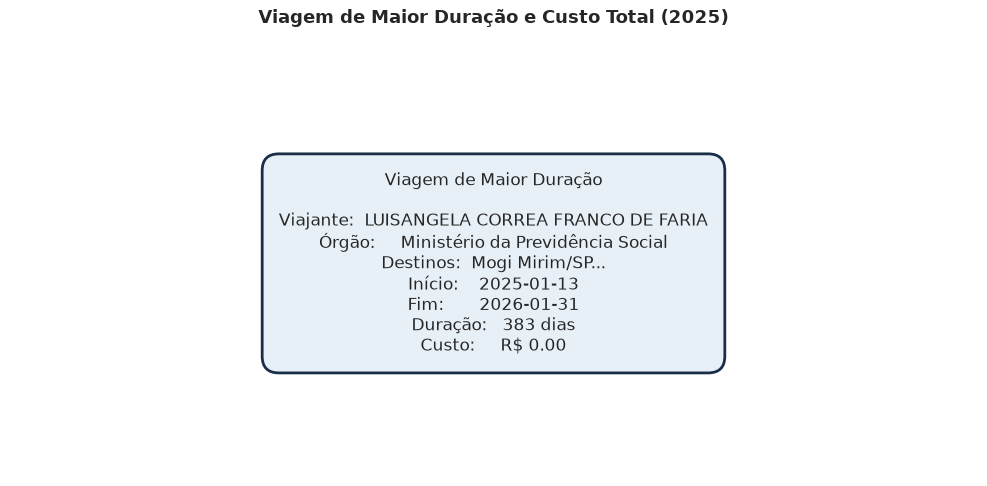

In [ ]:
# Gráfico P3 — Viagem de maior duração - Demosntração em forma de Card
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

# Pega os valores do dataframe
row = df_p3.iloc[0]

texto = (
    f"Viagem de Maior Duração\n\n"
    f"Viajante:  {row['nome_viajante']}\n"
    f"Órgão:     {row['nome_orgao_superior']}\n"
    f"Destinos:  {str(row['destinos'])[:80]}...\n"
    f"Início:    {row['data_inicio']}\n"
    f"Fim:       {row['data_fim']}\n"
    f"Duração:   {row['duracao_dias']} dias\n"
    f"Custo:     R$ {row['valor_total']:,.2f}".replace(",", ".")
)

ax.text(
    0.5, 0.5, texto,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="center",
    horizontalalignment="center",
    bbox=dict(boxstyle="round,pad=1", facecolor="#e8f0f7", edgecolor="#1a2e4a", linewidth=2)
)

ax.set_title("Viagem de Maior Duração e Custo Total (2025)",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_p3_1_maior_duracao.png", dpi=150, bbox_inches="tight")
plt.show()

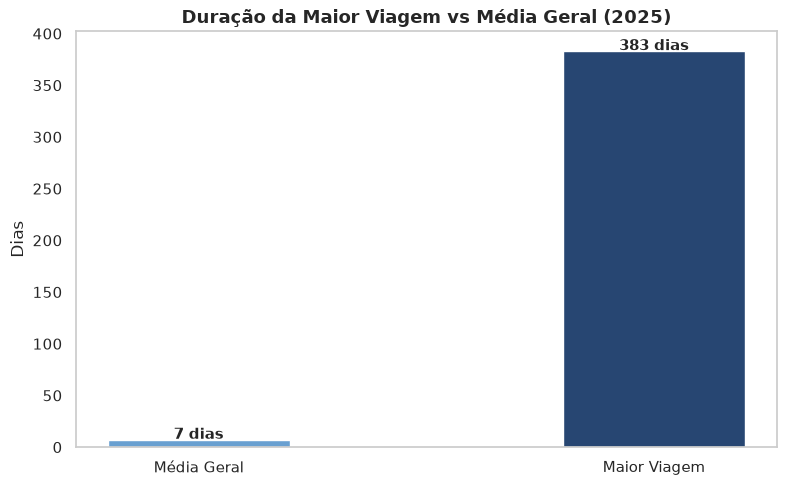

In [ ]:
# Gráfico P3.2 — Viagem de maior duração / média geral
media_duracao = pd.read_sql(
    "SELECT ROUND(AVG(duracao_dias), 1) AS media FROM silver_viagem WHERE duracao_dias IS NOT NULL",
    engine
).iloc[0]["media"]

fig, ax = plt.subplots(figsize=(8, 5))
categorias = ["Média Geral", "Maior Viagem"]
valores = [float(media_duracao), int(df_p3.iloc[0]["duracao_dias"])]
cores = ["#69a0d1", "#274672"]

bars = ax.bar(categorias, valores, color=cores, width=0.4)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.0f} dias",
        ha="center", fontweight="bold"
    )

ax.set_title("Duração da Maior Viagem vs Média Geral (2025)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Dias")
ax.grid(False)
plt.tight_layout()
plt.savefig("../reports/figures/grafico_p3_2_maior_duracao.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CAMADA GOLD — Tabela agregada com JOIN + GROUP BY
# ============================================================

with engine.connect() as conn:

    # Remove se já existir
    conn.execute(text("DROP TABLE IF EXISTS gold_resumo_orgaos"))
    conn.commit()

    # Cria tabela Gold agregada
    conn.execute(text("""
        CREATE TABLE gold_resumo_orgaos AS
        SELECT
            v.nome_orgao_superior,
            COUNT(DISTINCT v.id_viagem)         AS total_viagens,
            ROUND(SUM(v.valor_total), 2)        AS custo_total,
            ROUND(AVG(v.valor_total), 2)        AS custo_medio,
            ROUND(AVG(v.duracao_dias), 1)       AS duracao_media_dias,
            COUNT(DISTINCT p.tipo_pagamento)    AS tipos_pagamento,
            ROUND(SUM(p.valor), 2)              AS total_pago
        FROM silver_viagem v
        LEFT JOIN silver_pagamento p ON v.id_viagem = p.id_viagem
        WHERE v.valor_total IS NOT NULL
        GROUP BY v.nome_orgao_superior
        ORDER BY custo_total DESC
    """))
    conn.commit()

    print("Tabela gold_resumo_orgaos criada com sucesso!")

# Verifica resultado
df_gold = pd.read_sql("SELECT * FROM gold_resumo_orgaos LIMIT 5", engine)
print(df_gold.to_string(index=False))

Tabela gold_resumo_orgaos criada com sucesso!
                           nome_orgao_superior  total_viagens  custo_total  custo_medio  duracao_media_dias  tipos_pagamento   total_pago
     Ministério da Justiça e Segurança Pública          75742 7.511634e+09     42698.42               122.6                4 488831110.61
                          Ministério da Defesa          61912 3.402822e+08      3616.25                 6.4                4 156549767.91
                        Ministério da Educação          65295 2.716774e+08      2754.68                 3.0                4 111897434.35
              Ministério da Previdência Social           8190 1.915703e+08      9397.61                23.3                4  40659494.63
Ministério do Meio Ambiente e Mudança do Clima          19413 1.586827e+08      4896.10                 9.9                4  50123043.80


In [ ]:
# ============================================================
# CAMADA GOLD — View analítica
# ============================================================

with engine.connect() as conn:

    conn.execute(text("DROP VIEW IF EXISTS vw_gold_resumo_orgaos"))
    conn.commit()

    conn.execute(text("""
        CREATE VIEW vw_gold_resumo_orgaos AS
        SELECT
            v.nome_orgao_superior,
            COUNT(DISTINCT v.id_viagem)         AS total_viagens,
            ROUND(SUM(v.valor_total), 2)        AS custo_total,
            ROUND(AVG(v.valor_total), 2)        AS custo_medio,
            ROUND(AVG(v.duracao_dias), 1)       AS duracao_media_dias,
            COUNT(DISTINCT p.tipo_pagamento)    AS tipos_pagamento,
            ROUND(SUM(p.valor), 2)              AS total_pago
        FROM silver_viagem v
        LEFT JOIN silver_pagamento p ON v.id_viagem = p.id_viagem
        WHERE v.valor_total IS NOT NULL
        GROUP BY v.nome_orgao_superior
        ORDER BY custo_total DESC
    """))
    conn.commit()

    print("View vw_gold_resumo_orgaos criada com sucesso!")

# Testa a view
df_view = pd.read_sql("SELECT * FROM vw_gold_resumo_orgaos LIMIT 3", engine)
print(df_view.to_string(index=False))

View vw_gold_resumo_orgaos criada com sucesso!
                      nome_orgao_superior  total_viagens  custo_total  custo_medio  duracao_media_dias  tipos_pagamento   total_pago
Ministério da Justiça e Segurança Pública          75742 7.511634e+09     42698.42               122.6                4 488831110.61
                     Ministério da Defesa          61912 3.402822e+08      3616.25                 6.4                4 156549767.91
                   Ministério da Educação          65295 2.716774e+08      2754.68                 3.0                4 111897434.35


In [ ]:
# ============================================================
# PERGUNTA 4: Qual o tipo de pagamento com maior valor médio?
# ============================================================

query_p4 = """
    SELECT
        tipo_pagamento,
        COUNT(*)                        AS total_pagamentos,
        ROUND(AVG(valor), 2)            AS valor_medio,
        ROUND(SUM(valor), 2)            AS valor_total
    FROM silver_pagamento
    WHERE valor IS NOT NULL
        AND tipo_pagamento IS NOT NULL
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
"""

df_p4 = pd.read_sql(query_p4, engine)
print(df_p4.to_string(index=False))

           tipo_pagamento  total_pagamentos  valor_medio  valor_total
                  DIÁRIAS            401463      2078.28 834352643.52
                 PASSAGEM            188985      1878.34 354978915.13
Serviço correlato: seguro              4894       447.51   2190136.71
              RESTITUIÇÃO             11574       245.70   2843762.01


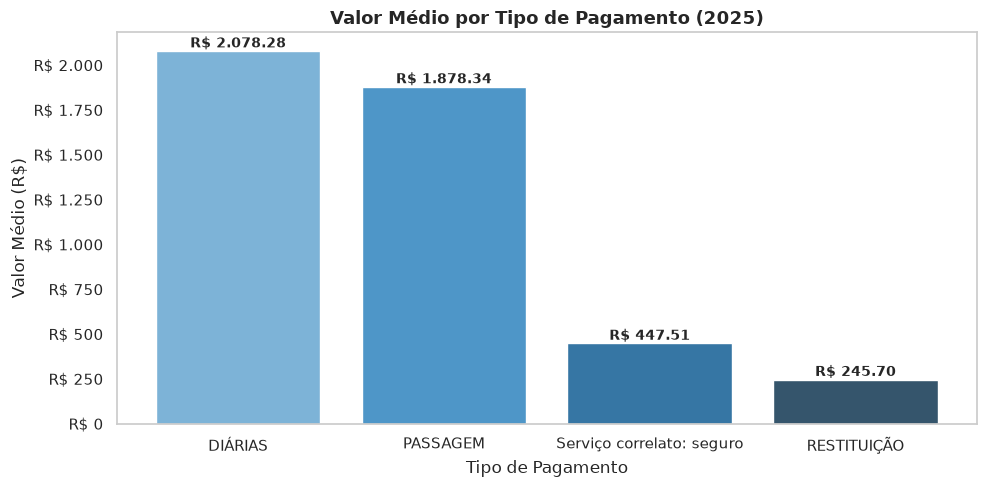

In [ ]:
# Gráfico P4 — Tipo de pagamento com maior valor médio
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    df_p4["tipo_pagamento"],
    df_p4["valor_medio"],
    color=sns.color_palette("Blues_d", len(df_p4))
)

for bar in bars:
    valor = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor + 20,
        f"R$ {valor:,.2f}".replace(",", "."),
        ha="center", fontsize=10, fontweight="bold"
    )

ax.set_title("Valor Médio por Tipo de Pagamento (2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tipo de Pagamento")
ax.set_ylabel("Valor Médio (R$)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", "."))
)
ax.grid(False)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_p4_pagamento.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# PERGUNTA 5: Qual o meio de transporte mais usado nos trechos?
# ============================================================

query_p5 = """
    SELECT
        meio_transporte,
        COUNT(*)                        AS total_trechos,
        ROUND(COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER(), 2)    AS percentual
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL
        AND meio_transporte != ''
    GROUP BY meio_transporte
    ORDER BY total_trechos DESC
"""

df_p5 = pd.read_sql(query_p5, engine)
print(df_p5.to_string(index=False))

meio_transporte  total_trechos  percentual
Veículo Oficial         386424       50.62
          Aéreo         232666       30.48
     Rodoviário          64970        8.51
Veículo Próprio          42846        5.61
       Inválido          26659        3.49
        Fluvial           8429        1.10
    Ferroviário            874        0.11
       Marítimo            481        0.06


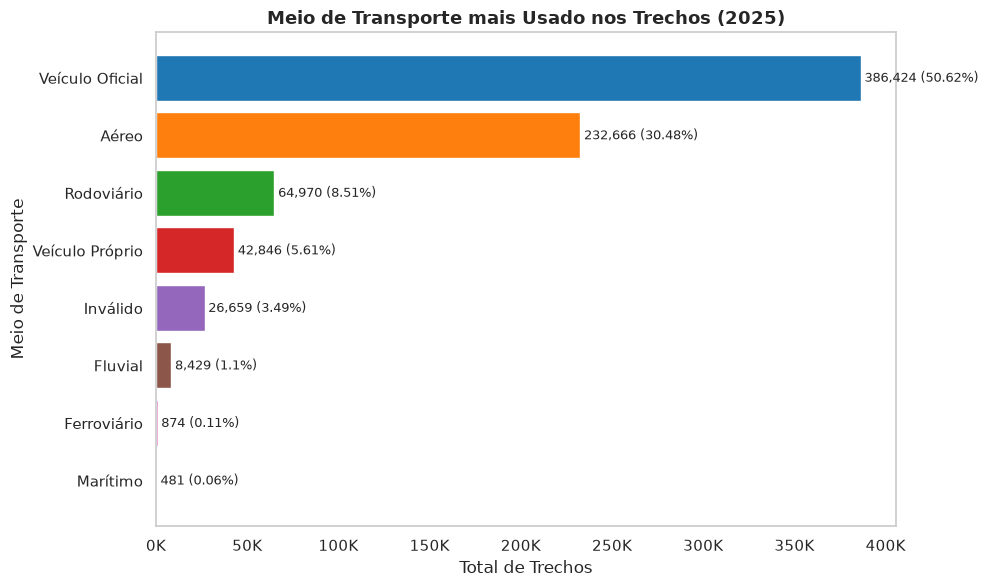

In [ ]:
# Gráfico P5 — Meio de transporte mais usado
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_p5["meio_transporte"],
    df_p5["total_trechos"],
    color=sns.color_palette("tab10", len(df_p5))
)

ax.invert_yaxis()

for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor + 2000,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,.0f} ({df_p5.loc[df_p5['total_trechos']==int(valor), 'percentual'].values[0]}%)",
        va="center", fontsize=9
    )

ax.set_title("Meio de Transporte mais Usado nos Trechos (2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Total de Trechos")
ax.set_ylabel("Meio de Transporte")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K")
)
ax.grid(False)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_p5_transporte.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# PERGUNTA 6: Qual UF de destino aparece em mais trechos?
# ============================================================

query_p6 = """
    SELECT
        destino_uf,
        COUNT(*)                        AS total_trechos,
        ROUND(COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER(), 2)    AS percentual
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL
        AND destino_uf != ''
    GROUP BY destino_uf
    ORDER BY total_trechos DESC
    LIMIT 10
"""

df_p6 = pd.read_sql(query_p6, engine)
print(df_p6.to_string(index=False))

        destino_uf  total_trechos  percentual
         São Paulo          82722       11.05
  Distrito Federal          79962       10.68
      Minas Gerais          50965        6.81
    Rio de Janeiro          44197        5.90
            Paraná          42603        5.69
              Pará          40044        5.35
 Rio Grande do Sul          38684        5.17
Mato Grosso do Sul          30516        4.08
             Bahia          28375        3.79
        Pernambuco          28372        3.79


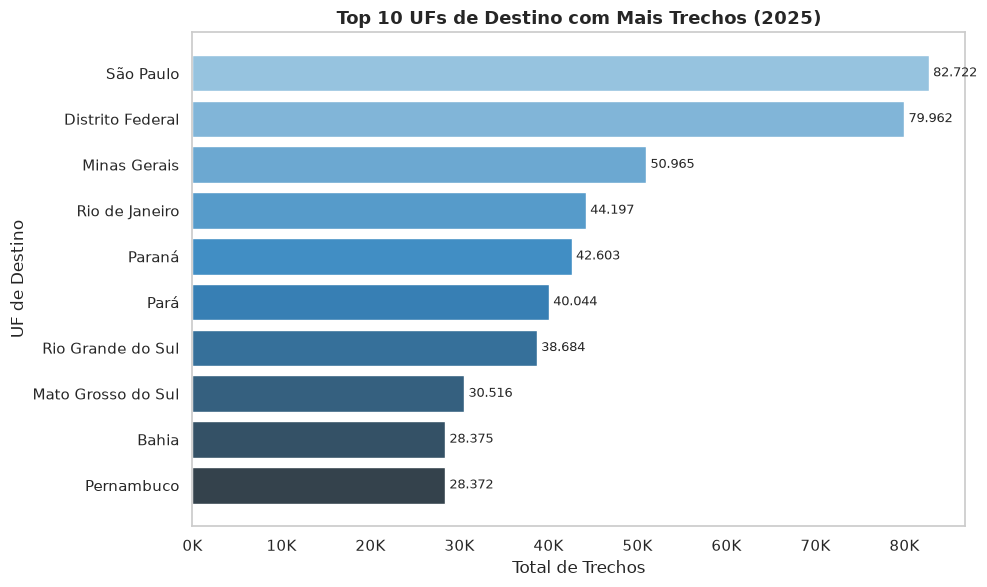

In [ ]:
# Gráfico P6 — UF de destino com mais trechos
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_p6["destino_uf"],
    df_p6["total_trechos"],
    color=sns.color_palette("Blues_d", len(df_p6))
)

ax.invert_yaxis()

for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor + 500,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center", fontsize=9
    )

ax.set_title("Top 10 UFs de Destino com Mais Trechos (2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Total de Trechos")
ax.set_ylabel("UF de Destino")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K")
)
ax.grid(False)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_p6_uf_destino.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# PERGUNTA 7: Qual órgão pagou mais no total?
# ============================================================

query_p7 = """
    SELECT
        v.nome_orgao_superior,
        COUNT(DISTINCT p.id_viagem)     AS total_viagens,
        ROUND(SUM(p.valor), 2)          AS total_pago
    FROM silver_pagamento p
    JOIN silver_viagem v ON p.id_viagem = v.id_viagem
    WHERE p.valor IS NOT NULL
        AND v.nome_orgao_superior IS NOT NULL
    GROUP BY v.nome_orgao_superior
    ORDER BY total_pago DESC
    LIMIT 1
"""

df_p7 = pd.read_sql(query_p7, engine)
print(df_p7.to_string(index=False))

                           nome_orgao_superior  total_viagens   total_pago
     Ministério da Justiça e Segurança Pública          75633 488831110.61
                          Ministério da Defesa          61388 156549767.91
                        Ministério da Educação          60011 111897434.35
Ministério do Meio Ambiente e Mudança do Clima          13397  50123043.80
              Ministério da Previdência Social           7911  40659494.63


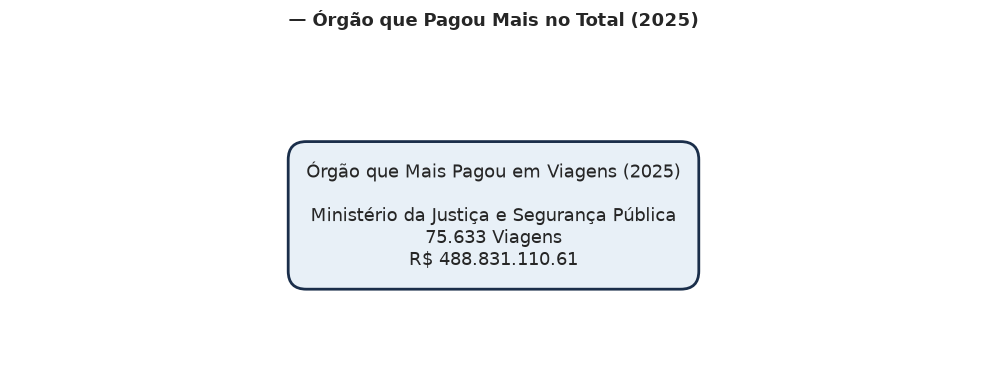

In [ ]:
# Gráfico P7 — Órgão que pagou mais no total
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

row = df_p7.iloc[0]

texto = (
    f"Órgão que Mais Pagou em Viagens (2025)\n\n"
    f"{row['nome_orgao_superior']}\n"
    f"{int(row['total_viagens']):,} Viagens\n"
    f"R$ {row['total_pago']:,.2f}".replace(",", ".")
)

ax.text(
    0.5, 0.5, texto,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment="center",
    horizontalalignment="center",
    bbox=dict(boxstyle="round,pad=1", facecolor="#e8f0f7",
              edgecolor="#1a2e4a", linewidth=2)
)

ax.set_title("— Órgão que Pagou Mais no Total (2025)",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("../reports/figures/grafico_p7_orgao_pagamento.png", dpi=150, bbox_inches="tight")
plt.show()